<a href="https://colab.research.google.com/github/fcoliveira-utfpr/relacoes_fisicas_ambiente/blob/main/codigos_python/aula_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 04 (extra) · Notebook auxiliar: o solo entre o clima e a produtividade

**Disciplina:** Relações Físicas do Ambiente Agrícola

| Seção | Conteúdo |
|---|---|
| 1–2 | Bibliotecas, configurações e **inspeção dos assets** |
| 3 | Construção das camadas: solo, clima e água disponível (ANA e pedotransferência) |
| 4 | Amostra estratificada de pontos no Paraná |
| 5 | **Bloco A:** solo × clima (Spearman, Köppen, Holdridge, Kruskal-Wallis, importância de variáveis) |
| 6 | **Bloco B:** água disponível da ANA × pedotransferência |
| 7 | **Bloco C:** CAD do solo no MZA-FAO × produtividade do IBGE (soja) |

As etapas pesadas (amostra, mapas, estatística zonal, séries do Xavier e SIDRA) são salvas em `dados/`. Ao reexecutar, o notebook lê os arquivos em vez de repetir as extrações. Para refazer uma etapa, apague o arquivo correspondente.

# 1. Bibliotecas e autenticação
___

In [ ]:
!pip install -q agrometeorologiapy geobr

import os, io, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from scipy.stats import kruskal, spearmanr, pearsonr
import ee
import geobr
import agrometeorologiapy as amp

ID_PROJETO = 'fcoliveira'
ee.Authenticate()
ee.Initialize(project=ID_PROJETO)
print('Earth Engine conectado ao projeto:', ID_PROJETO)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 34.4 MB/s eta 0:00:00
Earth Engine conectado ao projeto: fcoliveira


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


# 2. Configurações e inspeção dos assets
___

Execute primeiro a célula de configurações com os valores padrão (`None`) e depois a de inspeção. Com o resultado da inspeção, ajuste os parâmetros marcados com 🔧 e execute a configuração de novo.

In [ ]:
# ---------- Assets ----------
PREFIXO = 'projects/mapbiomas-public/assets/brazil/soil/collection3/'
ASSETS = {
    'argila':  PREFIXO + 'mapbiomas_brazil_collection3_soil_clay_fraction_v1',
    'silte':   PREFIXO + 'mapbiomas_brazil_collection3_soil_silt_fraction_v1',
    'areia':   PREFIXO + 'mapbiomas_brazil_collection3_soil_sand_fraction_v1',
    'textura': PREFIXO + 'mapbiomas_brazil_collection3_soil_textural_class_v1',
}
ASSET_AWC = 'projects/fcoliveira/assets/AWC_br'

# 🔧 Bandas a usar (None = primeira banda do asset)
BANDA = {'argila': None, 'silte': None, 'areia': None, 'textura': None}

# 🔧 Carbono orgânico (None = procura automática na pasta da coleção 3)
ASSET_COS = None
BANDA_COS = None          # None = última banda (ano mais recente, se for série)

# 🔧 Água disponível da ANA
CAMPO_AWC = None          # None = detecção automática do atributo numérico
FATOR_AWC = 1.0           # multiplicador para converter o valor da ANA em mm/cm

# 🔧 Legenda das classes texturais {código: nome}; vazio = mostra o código
CLASSES_TEXTURA = {}

# ---------- Pedotransferência (Saxton & Rawls, 2006) ----------
MO_PTF = 2.5              # matéria orgânica (%) fixa

# ---------- Amostragem ----------
PONTOS_POR_CLASSE = 250
ESCALA_AMOSTRA = 1000     # m

# ---------- Bloco C ----------
ASSET_LULC = ('projects/mapbiomas-public/assets/brazil/lulc/collection9/'
              'mapbiomas_collection90_integration_v1')
ANO_LULC = 2023
CLASSE_SOJA = 39
N_MUNICIPIOS = 25         # municípios com maior área de soja
ANO_COLHEITA_INI, ANO_COLHEITA_FIM = 2014, 2023   # safras 2013/14 a 2022/23
SEMEADURA_MMDD = '10-21'  # data fixa de semeadura da soja
CAD_FIXA = 50.0           # mm (Battisti et al., 2013)

PASTA_FIG, PASTA_DADOS = 'figuras', 'dados'
os.makedirs(PASTA_FIG, exist_ok=True)
os.makedirs(PASTA_DADOS, exist_ok=True)
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 110})


def salvar(fig, nome):
    caminho = os.path.join(PASTA_FIG, nome)
    fig.savefig(caminho, dpi=200, bbox_inches='tight')
    print('Figura salva em:', caminho)


parana = (ee.FeatureCollection('FAO/GAUL/2015/level1')
          .filter(ee.Filter.eq('ADM0_NAME', 'Brazil'))
          .filter(ee.Filter.eq('ADM1_NAME', 'Parana')))
geom = parana.geometry()

/usr/local/lib/python3.13/dist-packages/ee/deprecation.py:215: DeprecationWarning: 

Attention required for FAO/GAUL/2015/level1! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by FAO/GAUL/2025/level1

Learn more: https://developers.google.com/earth-engine/datasets/catalog/FAO_GAUL_2015_level1

  warnings.warn(warning, category=DeprecationWarning)


In [ ]:
# =================== INSPEÇÃO DOS ASSETS ===================
def resumo_imagem(img, escala=5000):
    """Percentis 1, 50 e 99 de cada banda no Paraná."""
    return img.reduceRegion(ee.Reducer.percentile([1, 50, 99]), geom, escala,
                            bestEffort=True, maxPixels=1e9).getInfo()

print('=== Granulometria e textura ===')
for nome, caminho in ASSETS.items():
    # Como os assets são salvos como ImageCollection na Coleção 3,
    # carregamos a coleção e pegamos a primeira imagem (.first())
    col = ee.ImageCollection(caminho)
    img = col.first()
    bandas = img.bandNames().getInfo()
    print(f'\n{nome}: {len(bandas)} banda(s) → {bandas[:6]}{" ..." if len(bandas) > 6 else ""}')
    print(f'  escala nominal: {img.projection().nominalScale().getInfo():.0f} m')
    print('  percentis (1, 50, 99) da 1 banda:', resumo_imagem(img.select(0)))

print('\n=== Assets na pasta da coleo 3 ===')
lista_assets = ee.data.listAssets({'parent': PREFIXO.rstrip('/')})['assets']
for a in lista_assets:
    print(f"  {a['type']:17s} {a['name']}")

print('\n=== gua disponvel (ANA) ===')
awc = ee.FeatureCollection(ASSET_AWC)
primeira = awc.first().getInfo()['properties']
print('  feies:', awc.size().getInfo())
for k, v in primeira.items():
    print(f'  {k:25s} {v}')

=== Granulometria e textura ===

argila: 1 banda(s) → ['clay_fraction']
  escala nominal: 30 m
  percentis (1, 50, 99) da 1 banda: {'clay_fraction_p1': 12, 'clay_fraction_p50': 46.999999999999986, 'clay_fraction_p99': 70}

silte: 1 banda(s) → ['silt_fraction']
  escala nominal: 30 m
  percentis (1, 50, 99) da 1 banda: {'silt_fraction_p1': 4, 'silt_fraction_p50': 24.999999999999943, 'silt_fraction_p99': 43}

areia: 1 banda(s) → ['sand_fraction']
  escala nominal: 30 m
  percentis (1, 50, 99) da 1 banda: {'sand_fraction_p1': 5.000000000000003, 'sand_fraction_p50': 20.99999999999998, 'sand_fraction_p99': 82.99999999999999}

textura: 1 banda(s) → ['textural_class']
  escala nominal: 30 m
  percentis (1, 50, 99) da 1 banda: {'textural_class_p1': 2, 'textural_class_p50': 2.9999999999999534, 'textural_class_p99': 9.000000000000002}

=== Assets na pasta da coleo 3 ===
  IMAGE             projects/mapbiomas-public/assets/brazil/soil/collection3/mapbiomas_brazil_collection3_soil_carbon_v1


## 2.1 Resolução automática dos parâmetros não definidos

Esta célula preenche o que ficou como `None`, com regras simples, e **imprime as escolhas** para você conferir:

- **Granulometria:** se o percentil 99 passar de 100, os valores estão em g kg⁻¹ e são divididos por 10.
- **Carbono:** procura na pasta um asset com "organic", "carbon", "soc" ou "stock" no nome; em coleção, usa a imagem mais recente; em imagem com várias bandas, a última.
- **ANA:** escolhe o primeiro atributo numérico com "awc", "ad", "cad" ou "agua" no nome.

In [ ]:
# ---------- Unidade da granulometria ----------
FATOR_GRAN = {}
for nome in ['argila', 'silte', 'areia']:
    # Como os assets são coleções na Coleção 3, carregamos como ImageCollection e pegamos a primeira imagem
    img = ee.ImageCollection(ASSETS[nome]).first()
    img = img.select(BANDA[nome]) if BANDA[nome] else img.select(0)
    p99 = list(resumo_imagem(img).values())
    p99 = max(v for v in p99 if v is not None)
    FATOR_GRAN[nome] = 0.1 if p99 > 100 else 1.0
    print(f'{nome}: p99 = {p99:.1f} → fator {FATOR_GRAN[nome]} (resultado em %)')

# ---------- Carbono orgnico ----------
if ASSET_COS is None:
    chaves = ['organic', 'carbon', 'soc', 'stock']
    candidatos = [a for a in lista_assets if any(c in a['name'].lower() for c in chaves)]
    if not candidatos:
        raise ValueError('Carbono no encontrado: defina ASSET_COS manualmente.')
    ASSET_COS, TIPO_COS = candidatos[0]['name'], candidatos[0]['type']
else:
    TIPO_COS = ee.data.getAsset(ASSET_COS)['type']

if TIPO_COS == 'IMAGE_COLLECTION':
    img_cos = ee.ImageCollection(ASSET_COS).limit(1, 'system:time_start', False).first()
else:
    img_cos = ee.Image(ASSET_COS)
bandas_cos = img_cos.bandNames().getInfo()
BANDA_COS = BANDA_COS or bandas_cos[-1]
print(f'\nCarbono: {ASSET_COS} ({TIPO_COS}) → banda {BANDA_COS}')
print('  percentis (1, 50, 99):', resumo_imagem(img_cos.select(BANDA_COS)))

# ---------- Atributo da ANA ----------
if CAMPO_AWC is None:
    # Filtramos chaves que possam ser o atributo de água disponível no solo
    candidatas_awc = [k for k in primeira.keys() if any(c in k.lower() for c in ['awc', 'ad', 'cad', 'agua', 'gua'])]
    if candidatas_awc:
        CAMPO_AWC = candidatas_awc[0]
    else:
        numericos = [k for k, v in primeira.items() if isinstance(v, (int, float))]
        CAMPO_AWC = numericos[0] if numericos else 'AWC'

vals = awc.aggregate_array(CAMPO_AWC).getInfo()
vals = np.array([v for v in vals if v is not None], dtype=float)
print(f'\nANA: atributo {CAMPO_AWC}  mediana = {np.median(vals):.3f}  '
      f'p5p95 = {np.percentile(vals, 5):.3f}{np.percentile(vals, 95):.3f}')
print('  Se a mediana estiver muito longe de ~1 (mm/cm), ajuste FATOR_AWC.')

argila: p99 = 70.0 → fator 1.0 (resultado em %)
silte: p99 = 43.0 → fator 1.0 (resultado em %)
areia: p99 = 83.0 → fator 1.0 (resultado em %)

Carbono: projects/mapbiomas-public/assets/brazil/soil/collection3/mapbiomas_brazil_collection3_soil_carbon_v1 (IMAGE) → banda carbon_2024
  percentis (1, 50, 99): {'carbon_2024_p1': 0, 'carbon_2024_p50': 55.99999999999999, 'carbon_2024_p99': 105}

ANA: atributo AWC  mediana = 0.116  p5p95 = 0.0540.179
  Se a mediana estiver muito longe de ~1 (mm/cm), ajuste FATOR_AWC.


# 3. Camadas: solo, clima e água disponível
___

## 3.1 Pedotransferência de Saxton & Rawls (2006)

Com areia (S) e argila (C) em fração decimal e matéria orgânica (MO) em %:

- θ1500t = −0,024 · S + 0,487 · C + 0,006 · MO + 0,005 · S · MO − 0,013 · C · MO + 0,068 · S · C + 0,031
- θpmp = θ1500t + (0,14 · θ1500t − 0,02)
- θ33t = −0,251 · S + 0,195 · C + 0,011 · MO + 0,006 · S · MO − 0,027 · C · MO + 0,452 · S · C + 0,299
- θcc = θ33t + (1,283 · θ33t² − 0,374 · θ33t − 0,015)
- AD = (θcc − θpmp) · 10  [mm cm⁻¹]

A primeira célula confere os valores da tabela do roteiro antes de aplicar a equação no Earth Engine.

In [ ]:
def ptf_saxton_rawls(S, C, MO):
    """θcc, θpmp e AD (mm/cm). S e C em fração decimal; MO em %."""
    t1500 = (-0.024 * S + 0.487 * C + 0.006 * MO + 0.005 * S * MO
             - 0.013 * C * MO + 0.068 * S * C + 0.031)
    pmp = t1500 + (0.14 * t1500 - 0.02)
    t33 = (-0.251 * S + 0.195 * C + 0.011 * MO + 0.006 * S * MO
           - 0.027 * C * MO + 0.452 * S * C + 0.299)
    cc = t33 + (1.283 * t33 ** 2 - 0.374 * t33 - 0.015)
    return cc, pmp, (cc - pmp) * 10


for nome, S, C, MO in [('Muito argiloso', 0.20, 0.60, 2.5), ('Arenoso', 0.85, 0.10, 1.0)]:
    cc, pmp, ad = ptf_saxton_rawls(S, C, MO)
    print(f'{nome:15s} θcc = {cc:.3f}  θpmp = {pmp:.3f}  AD = {ad:.2f} mm/cm')
# Esperado: 0,457 / 0,350 / 1,07  e  0,115 / 0,064 / 0,50

Muito argiloso  θcc = 0.457  θpmp = 0.350  AD = 1.07 mm/cm
Arenoso         θcc = 0.115  θpmp = 0.064  AD = 0.50 mm/cm


In [ ]:
def banda(nome):
    # Como os assets são coleções na Coleção 3, carregamos como ImageCollection e pegamos a primeira imagem
    img = ee.ImageCollection(ASSETS[nome]).first()
    return img.select(BANDA[nome]) if BANDA[nome] else img.select(0)

# ---------- Solo ----------
argila = banda('argila').multiply(FATOR_GRAN['argila']).rename('argila')
silte  = banda('silte').multiply(FATOR_GRAN['silte']).rename('silte')
areia  = banda('areia').multiply(FATOR_GRAN['areia']).rename('areia')
textura = banda('textura').toInt().rename('textura')
cos = img_cos.select(BANDA_COS).rename('COS')

# ---------- gua disponvel: ANA ----------
ad_ana = (awc.filter(ee.Filter.notNull([CAMPO_AWC]))
             .reduceToImage([CAMPO_AWC], ee.Reducer.first())
             .multiply(FATOR_AWC).rename('AD_ANA'))

# ---------- gua disponvel: pedotransferncia ----------
ad_ptf = ee.Image().expression(
    """
    ((t33 + (1.283 * t33 * t33 - 0.374 * t33 - 0.015))
     - (t15 + (0.14 * t15 - 0.02))) * 10
    """,
    {
        't33': ee.Image().expression(
            '-0.251*S + 0.195*C + 0.011*MO + 0.006*S*MO - 0.027*C*MO + 0.452*S*C + 0.299',
            {'S': areia.divide(100), 'C': argila.divide(100), 'MO': MO_PTF}),
        't15': ee.Image().expression(
            '-0.024*S + 0.487*C + 0.006*MO + 0.005*S*MO - 0.013*C*MO + 0.068*S*C + 0.031',
            {'S': areia.divide(100), 'C': argila.divide(100), 'MO': MO_PTF}),
    }).max(0).rename('AD_PTF')

# ---------- Clima: normais 19912020 do TerraClimate ----------
tc = ee.ImageCollection('IDAHO_EPSCOR/TERRACLIMATE').filterDate('1991-01-01', '2021-01-01')

def normal_mensal(m):
    mes = tc.filter(ee.Filter.calendarRange(m, m, 'month')).mean()
    T = mes.select('tmmx').add(mes.select('tmmn')).multiply(0.1 / 2)   # C
    P = mes.select('pr')                                                # mm/ms
    return T.rename(f'T{m:02d}').addBands(P.rename(f'P{m:02d}'))

normais = ee.Image.cat([normal_mensal(m) for m in range(1, 13)])
anual = tc.select(['pet', 'def']).sum().multiply(0.1 / 30).rename(['ETP', 'DEF'])

pilha = ee.Image.cat([argila, silte, areia, textura, cos, ad_ana, ad_ptf,
                      normais, anual, ee.Image.pixelLonLat()])
print('Bandas da pilha:', pilha.bandNames().getInfo())

Bandas da pilha: ['argila', 'silte', 'areia', 'textura', 'COS', 'AD_ANA', 'AD_PTF', 'T01', 'P01', 'T02', 'P02', 'T03', 'P03', 'T04', 'P04', 'T05', 'P05', 'T06', 'P06', 'T07', 'P07', 'T08', 'P08', 'T09', 'P09', 'T10', 'P10', 'T11', 'P11', 'T12', 'P12', 'ETP', 'DEF', 'longitude', 'latitude']


# 4. Amostra estratificada
___

O mesmo número de pontos por classe textural, para que classes raras no Paraná (arenosas e siltosas) tenham representação suficiente.

In [ ]:
ARQ_AMOSTRA = os.path.join(PASTA_DADOS, 'amostra_solo_clima.csv')

if os.path.exists(ARQ_AMOSTRA):
    df = pd.read_csv(ARQ_AMOSTRA)
    print('Amostra lida do arquivo.')
else:
    amostra = pilha.stratifiedSample(
        numPoints=PONTOS_POR_CLASSE, classBand='textura', region=geom,
        scale=ESCALA_AMOSTRA, seed=42, tileScale=4, dropNulls=True, geometries=False)
    df = pd.DataFrame([f['properties'] for f in amostra.getInfo()['features']])
    df.to_csv(ARQ_AMOSTRA, index=False)
    print('Amostra salva em:', ARQ_AMOSTRA)

# ---------- Classificação climática dos pontos ----------
T = df[[f'T{m:02d}' for m in range(1, 13)]].to_numpy().T      # formato (12, n)
P = df[[f'P{m:02d}' for m in range(1, 13)]].to_numpy().T
df['koppen']    = amp.classificacao_koppen_grade(T, P, df['latitude'].values)['classe']
df['holdridge'] = amp.classificacao_holdridge_grade(T, P, df['latitude'].values)['classe']
df['T_anual'] = T.mean(axis=0)
df['P_anual'] = P.sum(axis=0)
df['classe_textural'] = df['textura'].map(CLASSES_TEXTURA).fillna(df['textura'].astype(str))

print(f'{len(df)} pontos')
print('\nPontos por classe textural:\n', df['classe_textural'].value_counts().to_string())
print('\nKöppen:\n', df['koppen'].value_counts().to_string())
print('\nHoldridge:\n', df['holdridge'].value_counts().to_string())

Amostra salva em: dados/amostra_solo_clima.csv
2332 pontos

Pontos por classe textural:
 classe_textural
2     250
3     250
6     250
5     250
9     250
11    250
7     250
8     250
4     243
12     76
1       9
14      4

Köppen:
 koppen
Cfa    1702
Cfb     396
Aw      159
Af       58
Am       17

Holdridge:
 holdridge
Floresta úmida subtropical               1764
Floresta úmida temperada quente           320
Floresta seca subtropical                 245
Floresta muito úmida temperada quente       3


# 5. Bloco A · Solo × clima
___

## 5.1 Correlação de Spearman

Figura salva em: figuras/aula04_spearman.png


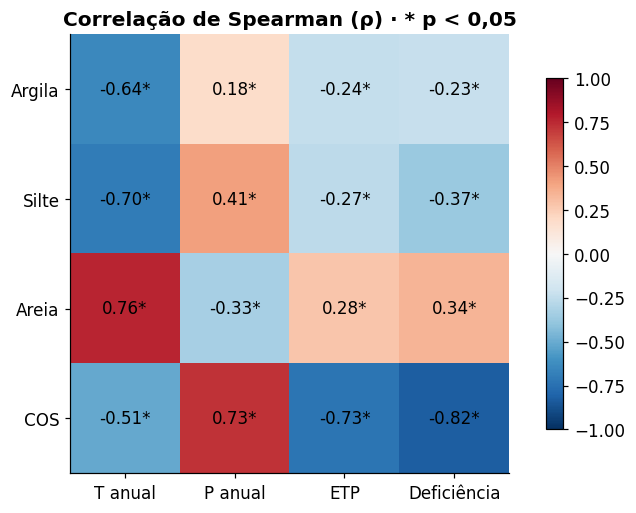

In [ ]:
VARS_SOLO = ['argila', 'silte', 'areia', 'COS']
VARS_CLIMA = ['T_anual', 'P_anual', 'ETP', 'DEF']

rho = pd.DataFrame(index=VARS_SOLO, columns=VARS_CLIMA, dtype=float)
pval = rho.copy()
for vs in VARS_SOLO:
    for vc in VARS_CLIMA:
        rho.loc[vs, vc], pval.loc[vs, vc] = spearmanr(df[vs], df[vc], nan_policy='omit')

fig, ax = plt.subplots(figsize=(7, 4.8))
im = ax.imshow(rho.values, cmap='RdBu_r', vmin=-1, vmax=1)
for i in range(len(VARS_SOLO)):
    for j in range(len(VARS_CLIMA)):
        sig = '*' if pval.iloc[i, j] < 0.05 else ''
        ax.text(j, i, f'{rho.iloc[i, j]:.2f}{sig}', ha='center', va='center', fontsize=11)
ax.set_xticks(range(len(VARS_CLIMA)))
ax.set_xticklabels(['T anual', 'P anual', 'ETP', 'Deficiência'])
ax.set_yticks(range(len(VARS_SOLO)))
ax.set_yticklabels(['Argila', 'Silte', 'Areia', 'COS'])
ax.set_title('Correlação de Spearman (ρ) · * p < 0,05', fontweight='bold')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
salvar(fig, 'aula04_spearman.png')
plt.show()

## 5.2 Kruskal-Wallis e tamanho de efeito por esquema climático

η²H = (H − k + 1) / (n − k). Referência de Cohen: 0,01 pequeno, 0,06 médio, 0,14 grande. Classes com menos de 10 pontos são descartadas.

Figura salva em: figuras/aula04_kruskal_eta2.png


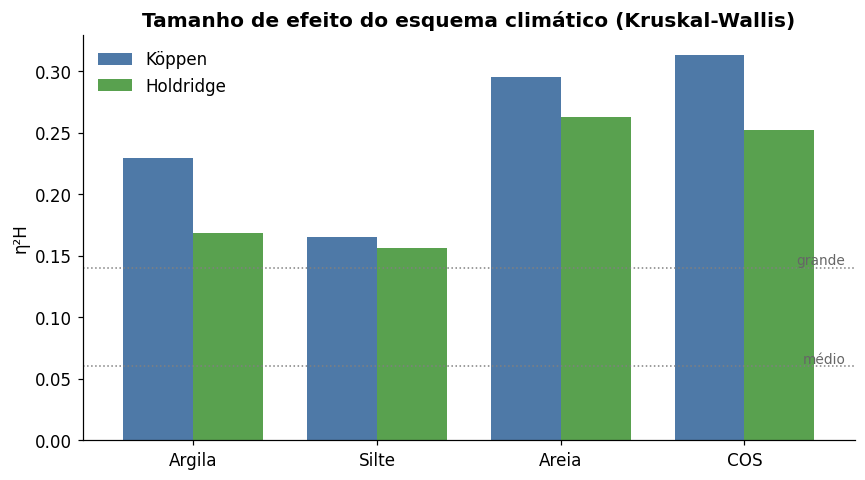

,variavel,esquema,k,H,p,eta2H
0,argila,koppen,5,537.2095,0.0,0.2291
1,argila,holdridge,3,394.8628,0.0,0.1689
2,silte,koppen,5,387.8496,0.0,0.1650
3,silte,holdridge,3,365.0626,0.0,0.1561
4,areia,koppen,5,690.4712,0.0,0.2950
5,areia,holdridge,3,612.4857,0.0,0.2625
6,COS,koppen,5,733.3070,0.0,0.3134
7,COS,holdridge,3,588.7333,0.0,0.2522


In [ ]:
def eta2_h(dados, var, grupo, n_min=10):
    grupos = [g[var].dropna().values for _, g in dados.groupby(grupo) if len(g) >= n_min]
    if len(grupos) < 2:                      # uma única classe: teste não se aplica
        return np.nan, np.nan, np.nan, len(grupos)
    H, p = kruskal(*grupos)
    k, n = len(grupos), sum(len(g) for g in grupos)
    return H, p, (H - k + 1) / (n - k), k


linhas = []
for var in VARS_SOLO:
    for esquema in ['koppen', 'holdridge']:
        H, p, e2, k = eta2_h(df, var, esquema)
        linhas.append(dict(variavel=var, esquema=esquema, k=k, H=H, p=p, eta2H=e2))
kw = pd.DataFrame(linhas)

fig, ax = plt.subplots(figsize=(8, 4.5))
largura = 0.38
xk = np.arange(len(VARS_SOLO))
for desloc, esquema, cor in [(-largura/2, 'koppen', '#4e79a7'), (largura/2, 'holdridge', '#59a14f')]:
    v = kw[kw['esquema'] == esquema].set_index('variavel').loc[VARS_SOLO, 'eta2H']
    ax.bar(xk + desloc, v.fillna(0), width=largura, color=cor,
           label='Köppen' if esquema == 'koppen' else 'Holdridge')
    for xi, vi in zip(xk + desloc, v):
        if pd.isna(vi):
            ax.text(xi, 0.003, 'n.a.', ha='center', fontsize=8, color='0.4')
for ref, txt in [(0.06, 'médio'), (0.14, 'grande')]:
    ax.axhline(ref, color='0.5', ls=':', lw=1)
    ax.text(len(VARS_SOLO) - 0.45, ref + 0.003, txt, color='0.4', fontsize=9, ha='right')
ax.set_xlim(-0.6, len(VARS_SOLO) - 0.4)
ax.set_xticks(xk)
ax.set_xticklabels(['Argila', 'Silte', 'Areia', 'COS'])
ax.set_ylabel('η²H')
ax.set_title('Tamanho de efeito do esquema climático (Kruskal-Wallis)', fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
salvar(fig, 'aula04_kruskal_eta2.png')
plt.show()

kw.round(4)

Figura salva em: figuras/aula04_boxplots_clima.png


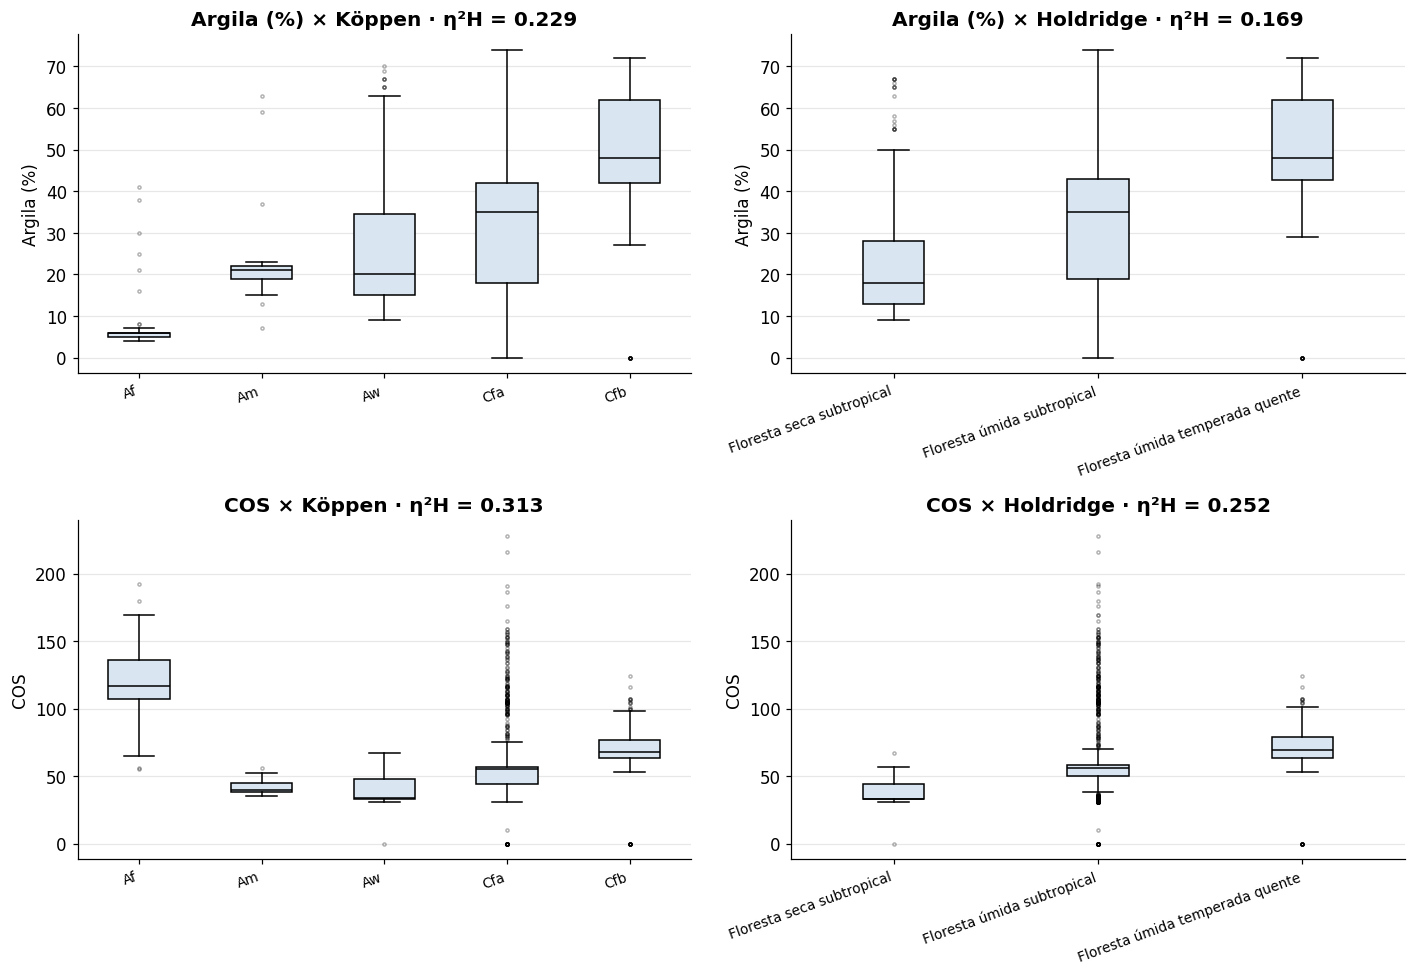

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for linha, var, rotulo in [(0, 'argila', 'Argila (%)'), (1, 'COS', 'COS')]:
    for col, esquema, titulo in [(0, 'koppen', 'Köppen'), (1, 'holdridge', 'Holdridge')]:
        ax = axes[linha, col]
        grupos = [(c, g[var].dropna().values) for c, g in df.groupby(esquema) if len(g) >= 10]
        ax.boxplot([g for _, g in grupos], patch_artist=True,
                   boxprops=dict(facecolor='#d9e6f2'),
                   medianprops=dict(color='black'),
                   flierprops=dict(marker='o', ms=2, alpha=0.3))
        ax.set_xticks(range(1, len(grupos) + 1))
        ax.set_xticklabels([c for c, _ in grupos], rotation=20, ha='right', fontsize=9)
        e2 = kw[(kw['variavel'] == var) & (kw['esquema'] == esquema)]['eta2H'].iloc[0]
        e2 = np.nan if e2 is None else e2
        ax.set_title(f'{rotulo} × {titulo} · η²H = {e2:.3f}', fontweight='bold')
        ax.set_ylabel(rotulo)
        ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
salvar(fig, 'aula04_boxplots_clima.png')
plt.show()

## 5.3 O carbono é mais explicado pelo clima ou pela argila?

Duas abordagens complementares:

- **Regressão com variáveis padronizadas** (escore z): o valor absoluto de cada β indica a importância relativa, supondo relação linear.
- **Importância por permutação em random forest**: quanto o desempenho do modelo cai quando cada variável é embaralhada, sem supor linearidade.

Figura salva em: figuras/aula04_importancia_cos.png


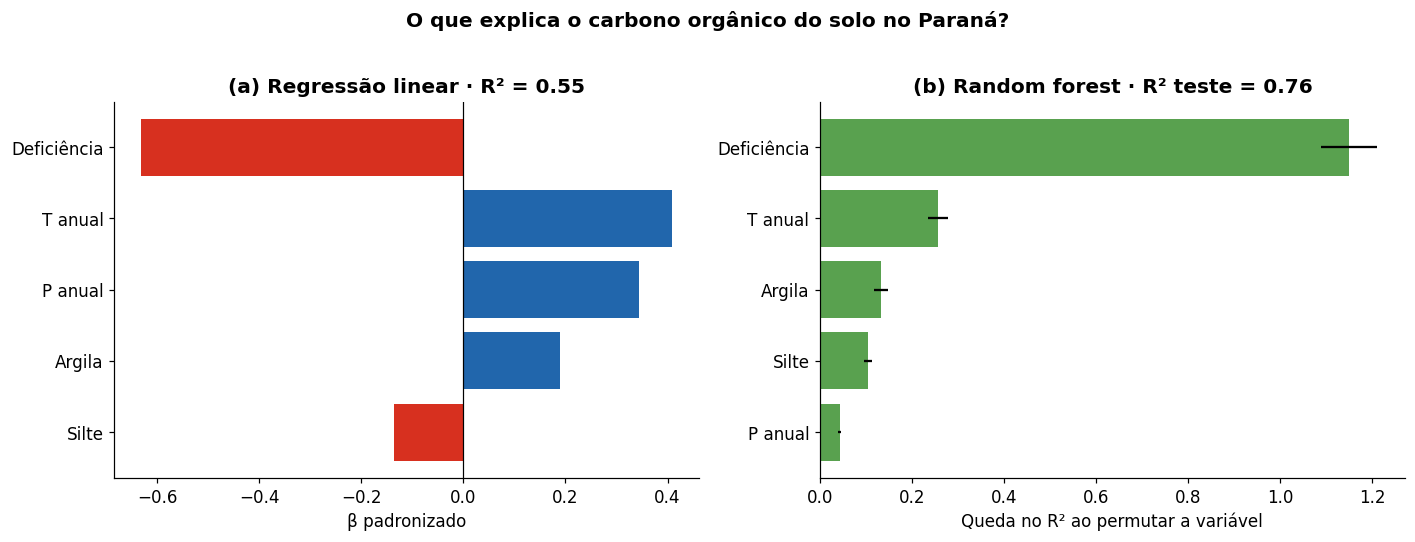

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

PREDITORES = ['T_anual', 'P_anual', 'DEF', 'argila', 'silte']
NOMES = ['T anual', 'P anual', 'Deficiência', 'Argila', 'Silte']
dados = df[PREDITORES + ['COS']].dropna()

# ---------- Regressão padronizada ----------
z = (dados - dados.mean()) / dados.std()
X = np.column_stack([np.ones(len(z)), z[PREDITORES].values])
beta, *_ = np.linalg.lstsq(X, z['COS'].values, rcond=None)
r2_lin = 1 - np.sum((z['COS'] - X @ beta) ** 2) / np.sum((z['COS'] - z['COS'].mean()) ** 2)

# ---------- Random forest ----------
Xtr, Xte, ytr, yte = train_test_split(dados[PREDITORES], dados['COS'],
                                      test_size=0.3, random_state=42)
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(Xtr, ytr)
imp = permutation_importance(rf, Xte, yte, n_repeats=20, random_state=42)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))
ordem = np.argsort(np.abs(beta[1:]))
ax1.barh(np.array(NOMES)[ordem], beta[1:][ordem],
         color=['#d7301f' if b < 0 else '#2166ac' for b in beta[1:][ordem]])
ax1.axvline(0, color='black', lw=0.8)
ax1.set_xlabel('β padronizado')
ax1.set_title(f'(a) Regressão linear · R² = {r2_lin:.2f}', fontweight='bold')

ordem = np.argsort(imp.importances_mean)
ax2.barh(np.array(NOMES)[ordem], imp.importances_mean[ordem],
         xerr=imp.importances_std[ordem], color='#59a14f')
ax2.set_xlabel('Queda no R² ao permutar a variável')
ax2.set_title(f'(b) Random forest · R² teste = {rf.score(Xte, yte):.2f}', fontweight='bold')

fig.suptitle('O que explica o carbono orgânico do solo no Paraná?', fontweight='bold', y=1.02)
plt.tight_layout()
salvar(fig, 'aula04_importancia_cos.png')
plt.show()

# 6. Bloco B · Água disponível: ANA × pedotransferência
___

In [ ]:
# ---------- Limites e grade do Paraná ----------
uf = geobr.read_state(code_state='PR', year=2020)
contorno = uf.geometry.union_all()
RES = 0.01
xmin, ymin, xmax, ymax = contorno.bounds
xmin, ymin, xmax, ymax = xmin - 0.05, ymin - 0.05, xmax + 0.05, ymax + 0.05
LARG = int(np.ceil((xmax - xmin) / RES))
ALT = int(np.ceil((ymax - ymin) / RES))


def mascara_poligono(geometria, forma):
    poligonos = list(geometria.geoms) if geometria.geom_type == 'MultiPolygon' else [geometria]
    lin, col = np.mgrid[0:forma[0], 0:forma[1]]
    centros = np.column_stack([(xmin + (col + 0.5) * RES).ravel(),
                               (ymax - (lin + 0.5) * RES).ravel()])
    dentro = np.zeros(len(centros), dtype=bool)
    for p in poligonos:
        dentro |= Path(np.asarray(p.exterior.coords)).contains_points(centros)
    return dentro.reshape(forma)


ARQ_MAPAS = os.path.join(PASTA_DADOS, 'mapas_ad.npz')
if os.path.exists(ARQ_MAPAS):
    mapas = dict(np.load(ARQ_MAPAS))
    print('Mapas lidos do arquivo.')
else:
    matriz = ee.data.computePixels({
        'expression': ee.Image.cat([ad_ana, ad_ptf]).clip(geom),
        'fileFormat': 'NUMPY_NDARRAY',
        'grid': {'dimensions': {'width': LARG, 'height': ALT},
                 'affineTransform': {'scaleX': RES, 'shearX': 0, 'translateX': xmin,
                                     'shearY': 0, 'scaleY': -RES, 'translateY': ymax},
                 'crsCode': 'EPSG:4326'},
    })
    mapas = {n: matriz[n].astype(float) for n in matriz.dtype.names}
    np.savez_compressed(ARQ_MAPAS, **mapas)

dentro = mascara_poligono(contorno, mapas['AD_ANA'].shape)
for n in mapas:
    mapas[n] = np.where(dentro & (mapas[n] > 0), mapas[n], np.nan)
mapas['DIF'] = mapas['AD_PTF'] - mapas['AD_ANA']

states_2020_simplified.parquet: 100%|██████████| 1.72M/1.72M [00:00<00:00, 29.3MB/s]


Figura salva em: figuras/aula04_mapas_ad.png


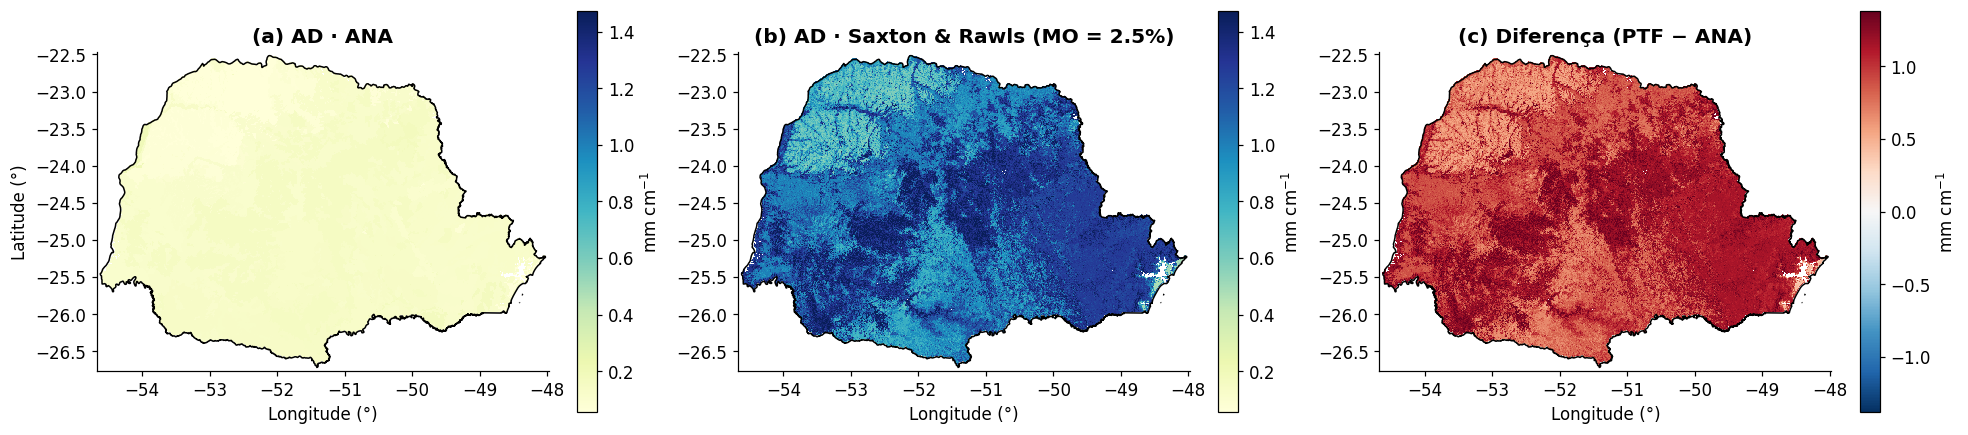

AD_ANA  média = 0.12  mediana = 0.12  p5–p95 = 0.05 a 0.15 mm/cm
AD_PTF  média = 1.12  mediana = 1.15  p5–p95 = 0.71 a 1.45 mm/cm
DIF     média = 1.00  mediana = 1.03  p5–p95 = 0.63 a 1.32 mm/cm


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
vmin = np.nanpercentile(np.r_[mapas['AD_ANA'].ravel(), mapas['AD_PTF'].ravel()], 2)
vmax = np.nanpercentile(np.r_[mapas['AD_ANA'].ravel(), mapas['AD_PTF'].ravel()], 98)
lim_dif = np.nanpercentile(np.abs(mapas['DIF']), 98)

for ax, chave, titulo, cmap, vv in [
        (axes[0], 'AD_ANA', '(a) AD · ANA', 'YlGnBu', (vmin, vmax)),
        (axes[1], 'AD_PTF', f'(b) AD · Saxton & Rawls (MO = {MO_PTF}%)', 'YlGnBu', (vmin, vmax)),
        (axes[2], 'DIF', '(c) Diferença (PTF − ANA)', 'RdBu_r', (-lim_dif, lim_dif))]:
    im = ax.imshow(mapas[chave], extent=[xmin, xmax, ymin, ymax], cmap=cmap,
                   vmin=vv[0], vmax=vv[1], interpolation='nearest')
    uf.boundary.plot(ax=ax, color='black', lw=1)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Longitude (°)')
    ax.set_ylabel('')
    fig.colorbar(im, ax=ax, shrink=0.75, label='mm cm$^{-1}$')
axes[0].set_ylabel('Latitude (°)')
plt.tight_layout()
salvar(fig, 'aula04_mapas_ad.png')
plt.show()

for chave in ['AD_ANA', 'AD_PTF', 'DIF']:
    v = mapas[chave]
    print(f'{chave:7s} média = {np.nanmean(v):.2f}  mediana = {np.nanmedian(v):.2f}  '
          f'p5–p95 = {np.nanpercentile(v, 5):.2f} a {np.nanpercentile(v, 95):.2f} mm/cm')

Figura salva em: figuras/aula04_ad_classes.png


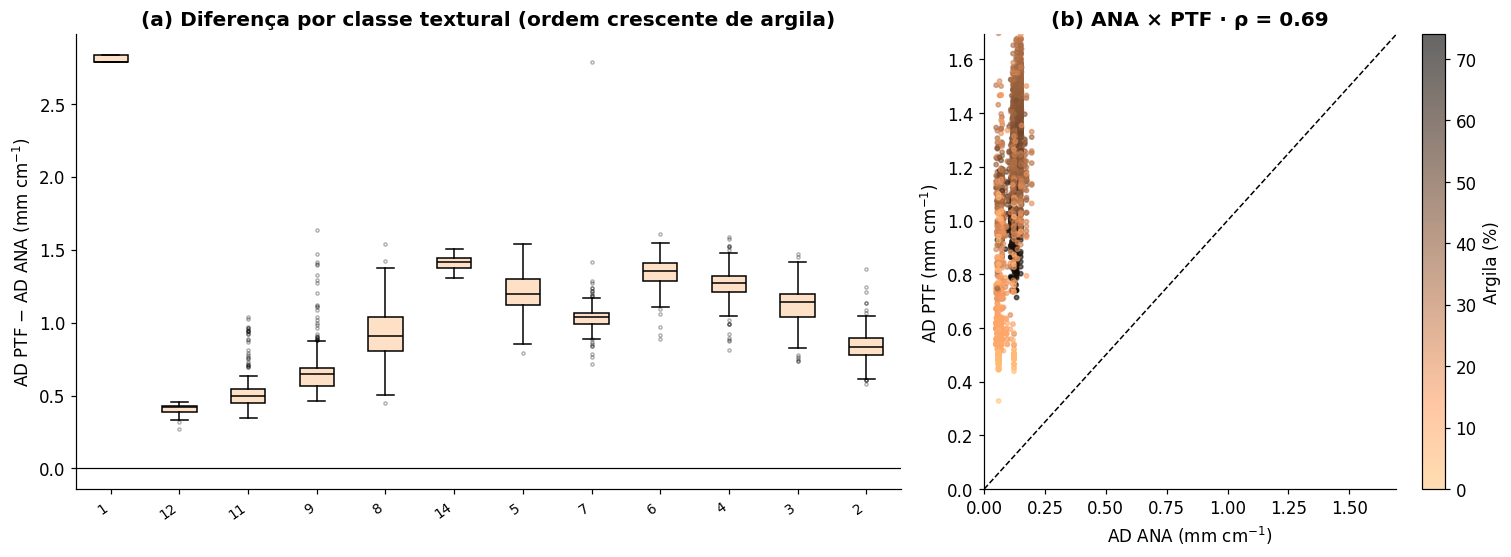

,argila,AD_ANA,AD_PTF,DIF_AD
classe_textural,,,,
1,0.0,0.15,2.94,2.79
12,5.0,0.06,0.49,0.42
11,12.0,0.06,0.56,0.50
9,15.0,0.07,0.71,0.65
8,25.0,0.07,1.00,0.91
14,34.0,0.12,1.54,1.41
5,36.0,0.14,1.32,1.19
7,37.0,0.12,1.16,1.04
6,38.0,0.15,1.49,1.36


In [ ]:
df['DIF_AD'] = df['AD_PTF'] - df['AD_ANA']
ordem = df.groupby('classe_textural')['argila'].median().sort_values().index

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2), gridspec_kw={'width_ratios': [1.6, 1]})
ax1.boxplot([df.loc[df['classe_textural'] == c, 'DIF_AD'].dropna() for c in ordem],
            patch_artist=True, boxprops=dict(facecolor='#fde0c5'),
            medianprops=dict(color='black'), flierprops=dict(marker='o', ms=2, alpha=0.3))
ax1.axhline(0, color='black', lw=0.8)
ax1.set_xticks(range(1, len(ordem) + 1))
ax1.set_xticklabels(ordem, rotation=35, ha='right', fontsize=9)
ax1.set_ylabel('AD PTF − AD ANA (mm cm$^{-1}$)')
ax1.set_title('(a) Diferença por classe textural (ordem crescente de argila)', fontweight='bold')

sc = ax2.scatter(df['AD_ANA'], df['AD_PTF'], c=df['argila'], cmap='copper_r', s=8, alpha=0.6)
lim = [0, np.nanpercentile(np.r_[df['AD_ANA'], df['AD_PTF']], 99) * 1.05]
ax2.plot(lim, lim, 'k--', lw=1)
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_xlabel('AD ANA (mm cm$^{-1}$)')
ax2.set_ylabel('AD PTF (mm cm$^{-1}$)')
r = df[['AD_ANA', 'AD_PTF']].corr(method='spearman').iloc[0, 1]
ax2.set_title(f'(b) ANA × PTF · ρ = {r:.2f}', fontweight='bold')
fig.colorbar(sc, ax=ax2, label='Argila (%)')

plt.tight_layout()
salvar(fig, 'aula04_ad_classes.png')
plt.show()

df.groupby('classe_textural')[['argila', 'AD_ANA', 'AD_PTF', 'DIF_AD']].median().loc[ordem].round(2)

# 7. Bloco C · CAD do solo no MZA-FAO × produtividade do IBGE
___

Fluxo:

1. Estatística zonal por município, **apenas nas áreas de soja** do MapBiomas: AD (ANA e PTF), argila, COS, área de soja e altitude.
2. Seleção dos `N_MUNICIPIOS` com maior área de soja.
3. Série diária do Xavier no centroide de cada município.
4. MZA-FAO da soja (parâmetros da Aula 03), semeadura fixa, uma simulação por safra e por fonte de CAD: **fixa (50 mm)**, **ANA** e **PTF**.
5. Rendimento da soja no SIDRA (PAM, tabela 1612), com remoção da tendência linear de cada município.
6. Correlação entre a eficiência climática simulada e o rendimento relativo à tendência.

## 7.1 Estatística zonal nas áreas de soja

In [ ]:
ARQ_ZONAL = os.path.join(PASTA_DADOS, 'zonal_municipios_soja.csv')

muni_gdf = geobr.read_municipality(code_muni='PR', year=2020)
muni_gdf['code_muni'] = muni_gdf['code_muni'].astype(int)

if os.path.exists(ARQ_ZONAL):
    zonal = pd.read_csv(ARQ_ZONAL)
    print('Estatística zonal lida do arquivo.')
else:
    simpl = muni_gdf[['code_muni', 'name_muni', 'geometry']].copy()
    simpl['geometry'] = simpl.geometry.simplify(0.005)
    fc_muni = ee.FeatureCollection(json.loads(simpl.to_json()))

    soja = ee.Image(ASSET_LULC).select(f'classification_{ANO_LULC}').eq(CLASSE_SOJA)
    medias = (ee.Image.cat([ad_ana, ad_ptf, argila, cos])
              .updateMask(soja)
              .reduceRegions(collection=fc_muni, reducer=ee.Reducer.mean(),
                             scale=250, tileScale=8))
    extras = (ee.Image.cat([soja.multiply(ee.Image.pixelArea()).divide(1e4).rename('area_soja_ha'),
                            ee.Image('USGS/SRTMGL1_003').rename('altitude')])
              .reduceRegions(collection=fc_muni,
                             reducer=ee.Reducer.sum().combine(ee.Reducer.mean(), sharedInputs=True),
                             scale=250, tileScale=8))

    def tabela(fc):
        return pd.DataFrame([f['properties'] for f in fc.getInfo()['features']])

    zonal = tabela(medias).merge(
        tabela(extras)[['code_muni', 'area_soja_ha_sum', 'altitude_mean']], on='code_muni')
    zonal = zonal.rename(columns={'area_soja_ha_sum': 'area_soja_ha', 'altitude_mean': 'altitude'})
    zonal.to_csv(ARQ_ZONAL, index=False)
    print('Estatística zonal salva em:', ARQ_ZONAL)

sel = zonal.dropna(subset=['AD_ANA', 'AD_PTF']).nlargest(N_MUNICIPIOS, 'area_soja_ha').copy()
cent = muni_gdf.set_index('code_muni').geometry.representative_point()
sel['lon'] = sel['code_muni'].map(cent.x)
sel['lat'] = sel['code_muni'].map(cent.y)
sel[['code_muni', 'name_muni', 'area_soja_ha', 'AD_ANA', 'AD_PTF', 'argila', 'COS', 'altitude']].round(2)

municipalities_2020_simplified.parquet: 100%|██████████| 20.2M/20.2M [00:00<00:00, 123MB/s] 


Estatística zonal salva em: dados/zonal_municipios_soja.csv


,code_muni,name_muni,area_soja_ha,AD_ANA,AD_PTF,argila,COS,altitude
376,4127502,Tibagi,114704.03,0.12,1.21,48.38,65.49,880.79
68,4104808,Cascavel,104303.28,0.12,1.03,60.83,58.06,664.03
134,4109401,Guarapuava,97619.93,0.13,0.95,63.66,79.47,1075.11
69,4104907,Castro,81458.37,0.13,1.23,47.99,74.02,953.74
378,4127700,Toledo,80613.51,0.11,1.07,59.49,55.48,504.47
24,4102000,Assis Chateaubriand,78795.94,0.11,1.04,60.85,54.86,383.90
274,4119905,Ponta Grossa,75386.34,0.13,1.23,47.37,66.95,879.78
182,4113205,Lapa,72776.11,0.13,1.23,50.05,70.27,861.41
190,4113700,Londrina,72258.42,0.12,1.02,61.33,55.68,566.66
247,4117701,Palmeira,71761.86,0.13,1.20,50.60,70.19,887.97


Figura salva em: figuras/aula04_municipios_soja.png


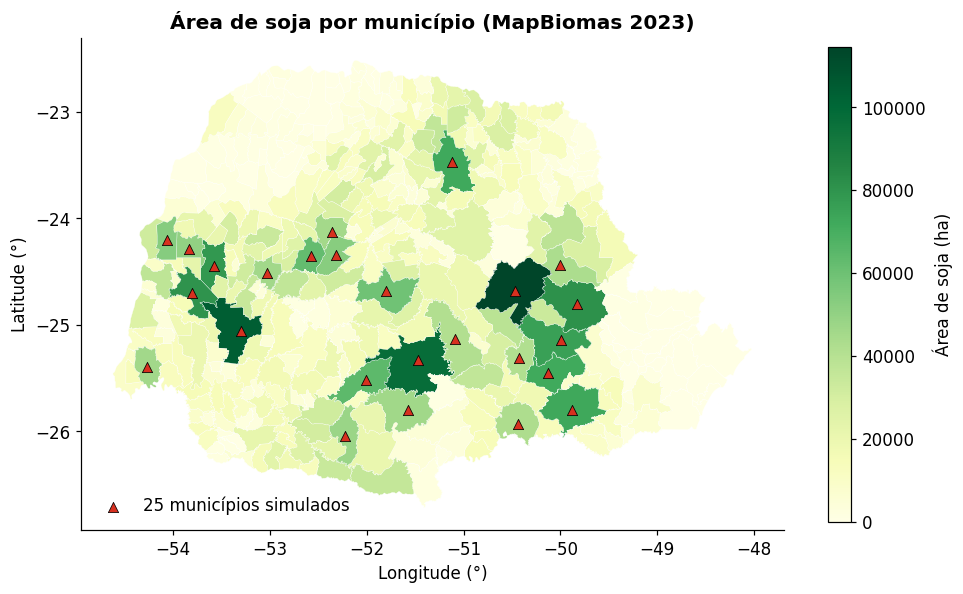

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6.5))
muni_gdf.merge(zonal[['code_muni', 'area_soja_ha']], on='code_muni', how='left').plot(
    column='area_soja_ha', cmap='YlGn', ax=ax, edgecolor='white', lw=0.2,
    legend=True, legend_kwds={'label': 'Área de soja (ha)', 'shrink': 0.7})
ax.scatter(sel['lon'], sel['lat'], marker='^', color='#d7301f', s=45,
           edgecolor='black', lw=0.5, label=f'{N_MUNICIPIOS} municípios simulados')
ax.set_title(f'Área de soja por município (MapBiomas {ANO_LULC})', fontweight='bold')
ax.legend(frameon=False, loc='lower left')
ax.set_xlabel('Longitude (°)'); ax.set_ylabel('Latitude (°)')
plt.tight_layout()
salvar(fig, 'aula04_municipios_soja.png')
plt.show()

## 7.2 Séries diárias do Xavier nos municípios selecionados

In [ ]:
ASSET_XAVIER = 'projects/ee-alexandrexavier/assets/BR-DWGD'
BANDAS_X = ['pr', 'Tmax', 'Tmin', 'Rs', 'RH', 'u2']
ESCALA_X = {'pr': (0.00686666, 225.0), 'Tmax': (0.00106815, 15.0), 'Tmin': (0.00106815, 15.0),
            'Rs': (0.15708661, -0.057087), 'RH': (0.39370079, -0.393701),
            'u2': (0.05905512, -0.059055)}
INI_X = f'{ANO_COLHEITA_INI - 1}-{SEMEADURA_MMDD}'
FIM_X = f'{ANO_COLHEITA_FIM}-05-01'


def serie_xavier(cod, lon, lat):
    arq = os.path.join(PASTA_DADOS, f'xavier_{cod}.csv')
    if os.path.exists(arq):
        return pd.read_csv(arq, parse_dates=['data'], index_col='data')
    col = ee.ImageCollection(ASSET_XAVIER).filterDate(INI_X, FIM_X).select(BANDAS_X)
    bruto = col.getRegion(ee.Geometry.Point([lon, lat]), scale=10000).getInfo()
    d = pd.DataFrame(bruto[1:], columns=bruto[0])
    d['data'] = pd.to_datetime(d['id'].str[-8:], format='%Y%m%d')
    d = d.set_index('data').sort_index()[BANDAS_X]
    if d['Tmax'].abs().max() > 100:
        for b, (m, s) in ESCALA_X.items():
            d[b] = d[b] * m + s
    d = d.rename(columns={'pr': 'Chuva', 'Rs': 'Qg', 'RH': 'UR'})
    d['Chuva'] = d['Chuva'].clip(lower=0)
    d['UR'] = d['UR'].clip(0, 100)
    d.to_csv(arq)
    return d


series = {}
for _, m in sel.iterrows():
    series[m['code_muni']] = serie_xavier(m['code_muni'], m['lon'], m['lat'])
    print(f"{m['name_muni']} ✔", end='  ')

Tibagi ✔  Cascavel ✔  Guarapuava ✔  Castro ✔  Toledo ✔  Assis Chateaubriand ✔  Ponta Grossa ✔  Lapa ✔  Londrina ✔  Palmeira ✔  Candói ✔  Mamborê ✔  Pitanga ✔  Terra Roxa ✔  Luiziana ✔  Palotina ✔  Mangueirinha ✔  Pinhão ✔  Ubiratã ✔  São Miguel do Iguaçu ✔  Campo Mourão ✔  Piraí do Sul ✔  São Mateus do Sul ✔  Teixeira Soares ✔  Prudentópolis ✔  

## 7.3 MZA-FAO da soja

Mesma formulação da Aula 03: ETo de Penman-Monteith FAO-56, kc pela curva da FAO-56, agregação decendial, PPBp com correção C3, balanço hídrico de Thornthwaite & Mather com CAD por decêndio e PA pelo produtório.

In [ ]:
SOJA = dict(ini=20, dev=30, flor=20, form=35, mat=20, kc=(0.40, 1.15, 0.50),
            ky=(0.2, 0.8, 1.0, 0.0), IAF=4.5, Cc=0.35, U=13.0, Zmax=0.5)
VEG = SOJA['ini'] + SOJA['dev']
LIMITES = np.cumsum([VEG, SOJA['flor'], SOJA['form'], SOJA['mat']])
CICLO = int(LIMITES[-1])
CIAF = 0.0093 + 0.185 * SOJA['IAF'] - 0.0175 * SOJA['IAF'] ** 2
ZR0 = 0.2


def preparar_diario(d, lat, altitude):
    """Variáveis astronômicas e ETo de Penman-Monteith FAO-56."""
    d = d.copy()
    d['Tmed'] = amp.temp_media_extremos(d['Tmax'], d['Tmin'])
    nda = d.index.dayofyear
    dec = amp.declinacao_solar(nda)
    Hn = amp.angulo_horario_nascer(lat, dec)
    d['Qo'] = amp.irradiancia_extraterrestre(lat, dec, Hn, amp.fator_correcao_distancia(nda))
    es = (amp.es_tetens(d['Tmax']) + amp.es_tetens(d['Tmin'])) / 2
    ea = amp.ea_umidade(es, d['UR'])
    qcs = (0.75 + 2e-5 * altitude) * d['Qo']
    rn = amp.saldo_radiacao(amp.boc_saldo(d['Qg'], r=0.23),
                            amp.bol_saldo(d['Tmax'], d['Tmin'], ea, np.minimum(d['Qg'], qcs), qcs))
    gamma = amp.constante_psicrometrica(amp.patm_altitude(altitude))
    d['ETo'] = amp.eto_penman_monteith_fao56(rn, 0, d['Tmed'], d['u2'], es, ea,
                                             amp.declive_pressao_vapor(d['Tmed']), gamma).clip(lower=0)
    return d


def kc_fao56(das):
    ki, km, ke = SOJA['kc']
    return np.select([das <= SOJA['ini'], das <= VEG, das <= LIMITES[2]],
                     [ki, ki + (km - ki) * (das - SOJA['ini']) / SOJA['dev'], km],
                     km + (ke - km) * (das - LIMITES[2]) / SOJA['mat'])


def correcao_c3(T):
    cTn = -0.0425 + 0.035 * T + 0.00325 * T**2 - 0.0000925 * T**3
    cTc = 0.583 + 0.014 * T + 0.0013 * T**2 - 0.000037 * T**3
    return np.clip(cTn, 0, None), np.clip(cTc, 0, None)


def simular_safra(d, data_sem, lat, cad_modo, ad):
    """Retorna PPf, PA (produtório) e EC de uma safra de soja."""
    s = d.loc[data_sem: data_sem + pd.Timedelta(days=CICLO - 1)].copy()
    if len(s) < CICLO * 0.95:
        return np.nan, np.nan, np.nan
    s['DAS'] = (s.index - data_sem).days + 1
    s['ETc'] = kc_fao56(s['DAS'].values) * s['ETo']
    if cad_modo == 'fixa':
        s['CAD'] = CAD_FIXA
    else:
        zr = np.minimum(ZR0 + (SOJA['Zmax'] - ZR0) * s['DAS'] / VEG, SOJA['Zmax'])
        s['CAD'] = ad * zr * 100
    s['dec'] = np.minimum((s.index.day - 1) // 10, 2)
    g = s.groupby([s.index.year, s.index.month, s['dec']]).agg(
        ND=('DAS', 'size'), DAS=('DAS', 'median'), Tmed=('Tmed', 'mean'),
        Qg=('Qg', 'mean'), Qo=('Qo', 'mean'), Chuva=('Chuva', 'sum'),
        ETc=('ETc', 'sum'), CAD=('CAD', 'mean')).reset_index(drop=True)
    g['fase'] = np.searchsorted(LIMITES, g['DAS'], side='left')

    # Produtividade potencial
    nN = ((g['Qg'] / g['Qo'] - 0.29 * np.cos(np.radians(lat))) / 0.52).clip(0, 1)
    cTn, cTc = correcao_c3(g['Tmed'].values)
    ppbp = (107.2 + 8.604 * g['Qo']) * cTc * nN + (31.7 + 5.234 * g['Qo']) * cTn * (1 - nN)
    cr = np.where(g['Tmed'] < 20, 0.6, 0.5)
    ppf = np.sum(ppbp * g['ND'] * CIAF * cr * SOJA['Cc']) / (1 - 0.01 * SOJA['U'])

    # Balanço hídrico e produtório
    g['ETr'] = amp.balanco_hidrico_cultura(g[['Chuva', 'ETc', 'CAD']])['ETR'].values
    f = g.groupby('fase')[['ETc', 'ETr']].sum().reindex(range(4))
    fatores = 1 - np.array(SOJA['ky']) * (1 - f['ETr'] / f['ETc'])
    pa = ppf * np.prod(np.clip(fatores.fillna(1).values, 0, None))
    return ppf, pa, pa / ppf


ARQ_SIM = os.path.join(PASTA_DADOS, 'simulacoes_mza_soja.csv')
if os.path.exists(ARQ_SIM):
    sim = pd.read_csv(ARQ_SIM)
    print('Simulações lidas do arquivo.')
else:
    linhas = []
    for _, m in sel.iterrows():
        d = preparar_diario(series[m['code_muni']], m['lat'], m['altitude'])
        for ano in range(ANO_COLHEITA_INI, ANO_COLHEITA_FIM + 1):
            data_sem = pd.Timestamp(f'{ano - 1}-{SEMEADURA_MMDD}')
            for modo, ad in [('fixa', None), ('ANA', m['AD_ANA']), ('PTF', m['AD_PTF'])]:
                ppf, pa, ec = simular_safra(d, data_sem, m['lat'], modo, ad)
                linhas.append(dict(code_muni=m['code_muni'], ano=ano, CAD=modo,
                                   PPf=ppf, PA=pa, EC=ec))
        print(f"{m['name_muni']} ✔", end='  ')
    sim = pd.DataFrame(linhas)
    sim.to_csv(ARQ_SIM, index=False)

sim.groupby('CAD')[['PPf', 'PA', 'EC']].describe().round(2)

Tibagi ✔  Cascavel ✔  Guarapuava ✔  Castro ✔  Toledo ✔  Assis Chateaubriand ✔  Ponta Grossa ✔  Lapa ✔  Londrina ✔  Palmeira ✔  Candói ✔  Mamborê ✔  Pitanga ✔  Terra Roxa ✔  Luiziana ✔  Palotina ✔  Mangueirinha ✔  Pinhão ✔  Ubiratã ✔  São Miguel do Iguaçu ✔  Campo Mourão ✔  Piraí do Sul ✔  São Mateus do Sul ✔  Teixeira Soares ✔  Prudentópolis ✔  

PPf                                                                \
      count     mean     std      min      25%      50%      75%      max   
CAD                                                                         
ANA   250.0  5227.67  287.36  4627.11  5014.44  5202.04  5440.55  5890.44   
PTF   250.0  5227.67  287.36  4627.11  5014.44  5202.04  5440.55  5890.44   
fixa  250.0  5227.67  287.36  4627.11  5014.44  5202.04  5440.55  5890.44   

         PA           ...                       EC                          \
      count     mean  ...      75%      max  count  mean   std   min   25%   
CAD                   ...                                                    
ANA   250.0  3135.19  ...  3924.42  5207.37  250.0  0.61  0.21  0.11  0.44   
PTF   250.0  3865.63  ...  4647.91  5243.69  250.0  0.75  0.21  0.12  0.64   
fixa  250.0  3927.41  ...  4664.98  5340.29  250.0  0.76  0.21  0.13  0.66   

                       
       50%   75%  max  
CAD                    
ANA   0.62  0.76  1.0  
PTF   0.81  0.91  1.0  
fixa  0.82  0.92  1.0  

[3 rows x 24 columns]

## 7.4 Rendimento da soja no SIDRA

O código do produto "Soja (em grão)" é obtido automaticamente dos metadados da tabela 1612, para não depender de um código fixo.

In [ ]:
ARQ_IBGE = os.path.join(PASTA_DADOS, 'ibge_soja_pr.csv')

if os.path.exists(ARQ_IBGE):
    ibge = pd.read_csv(ARQ_IBGE)
    print('Dados do IBGE lidos do arquivo.')
else:
    meta = pd.read_json('https://servicodados.ibge.gov.br/api/v3/agregados/1612/metadados',
                        typ='series')
    classif = [c for c in meta['classificacoes'] if c['id'] == 81][0]
    cod_soja = [c['id'] for c in classif['categorias'] if c['nome'].lower().startswith('soja')][0]
    print('Código do produto soja na tabela 1612:', cod_soja)

    anos = ','.join(str(a) for a in range(ANO_COLHEITA_INI, ANO_COLHEITA_FIM + 1))
    url = (f'https://apisidra.ibge.gov.br/values/t/1612/n6/in%20n3%2041'
           f'/v/112/p/{anos}/c81/{cod_soja}')
    bruto = pd.read_json(url)
    cab = bruto.iloc[0]
    col_mun = [c for c in bruto.columns if cab[c] == 'Município (Código)'][0]
    col_ano = [c for c in bruto.columns if cab[c] == 'Ano (Código)'][0]
    ibge = pd.DataFrame({
        'code_muni': pd.to_numeric(bruto[col_mun].iloc[1:], errors='coerce'),
        'ano': pd.to_numeric(bruto[col_ano].iloc[1:], errors='coerce'),
        'PO': pd.to_numeric(bruto['V'].iloc[1:], errors='coerce'),
    }).dropna()
    ibge.to_csv(ARQ_IBGE, index=False)
    print('Dados do IBGE salvos em:', ARQ_IBGE)


def razao_tendencia(g, n_min=6):
    """Rendimento observado dividido pela tendência linear do município."""
    g = g.dropna(subset=['PO'])
    if len(g) < n_min:
        return pd.Series(np.nan, index=g.index)
    coef = np.polyfit(g['ano'], g['PO'], 1)
    return g['PO'] / np.polyval(coef, g['ano'])


ibge = ibge[ibge['code_muni'].isin(sel['code_muni'])].copy()
ibge['PO_rel'] = ibge.groupby('code_muni', group_keys=False).apply(razao_tendencia)
ibge.describe().round(2)

Código do produto soja na tabela 1612: 2713
Dados do IBGE salvos em: dados/ibge_soja_pr.csv


/tmp/ipykernel_557/2126035941.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ibge['PO_rel'] = ibge.groupby('code_muni', group_keys=False).apply(razao_tendencia)


,code_muni,ano,PO,PO_rel
count,250.00,250.00,250.00,250.00
mean,4116889.92,2018.50,3455.36,1.00
std,8245.62,2.88,640.47,0.18
min,4102000.00,2014.00,352.00,0.14
25%,4113205.00,2016.00,3260.50,0.95
50%,4117909.00,2018.50,3542.00,1.00
75%,4125605.00,2021.00,3827.25,1.07
max,4128005.00,2023.00,4441.00,1.55


## 7.5 A CAD do solo melhora o modelo?

Duas comparações:

- **Variação entre anos:** EC simulada × rendimento relativo à tendência (PO_rel), com todos os municípios e safras juntos. A pergunta é se o modelo acerta os anos bons e ruins.
- **Variação entre municípios:** PA média × PO média de cada município.

Figura salva em: figuras/aula04_ec_vs_ibge.png


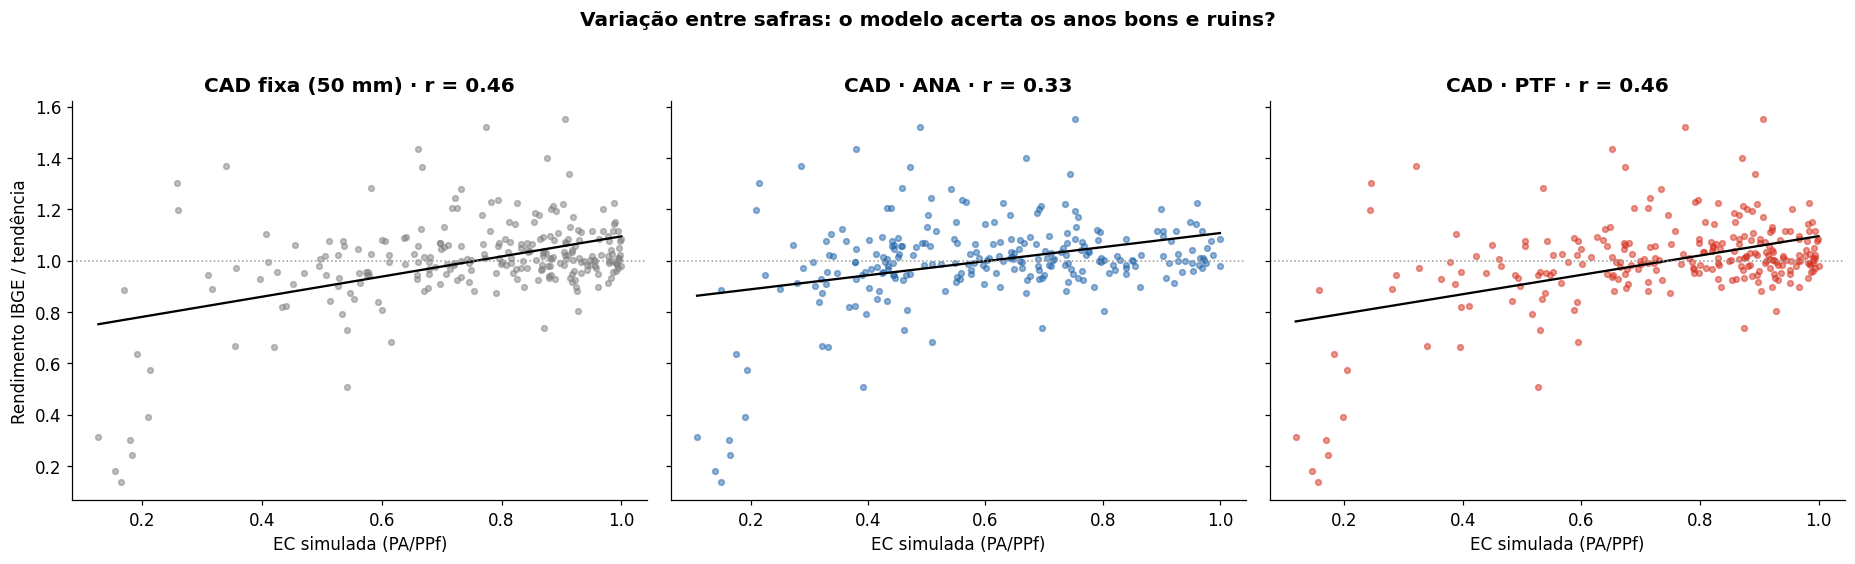

,r_entre_anos,p_anos,r_entre_municipios,p_municipios,n
CAD,,,,,
CAD fixa (50 mm),0.460,0.0,0.658,0.000,250
CAD · ANA,0.334,0.0,0.556,0.004,250
CAD · PTF,0.456,0.0,0.679,0.000,250


In [ ]:
base = sim.merge(ibge, on=['code_muni', 'ano'], how='inner').dropna(subset=['EC', 'PO_rel'])
FONTES = ['fixa', 'ANA', 'PTF']
ROTULOS = {'fixa': f'CAD fixa ({CAD_FIXA:.0f} mm)', 'ANA': 'CAD · ANA', 'PTF': 'CAD · PTF'}
CORES = {'fixa': '0.5', 'ANA': '#2166ac', 'PTF': '#d7301f'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
res = []
for ax, fonte in zip(axes, FONTES):
    b = base[base['CAD'] == fonte]
    r_anos, p_anos = pearsonr(b['EC'], b['PO_rel'])
    medias = b.groupby('code_muni')[['PA', 'PO']].mean()
    r_mun, p_mun = pearsonr(medias['PA'], medias['PO'])
    res.append(dict(CAD=ROTULOS[fonte], r_entre_anos=r_anos, p_anos=p_anos,
                    r_entre_municipios=r_mun, p_municipios=p_mun, n=len(b)))
    ax.scatter(b['EC'], b['PO_rel'], s=14, alpha=0.5, color=CORES[fonte])
    coef = np.polyfit(b['EC'], b['PO_rel'], 1)
    xx = np.linspace(b['EC'].min(), b['EC'].max(), 50)
    ax.plot(xx, np.polyval(coef, xx), 'k-', lw=1.5)
    ax.axhline(1, color='0.6', ls=':', lw=1)
    ax.set_title(f'{ROTULOS[fonte]} · r = {r_anos:.2f}', fontweight='bold')
    ax.set_xlabel('EC simulada (PA/PPf)')
axes[0].set_ylabel('Rendimento IBGE / tendência')
fig.suptitle('Variação entre safras: o modelo acerta os anos bons e ruins?', fontweight='bold', y=1.02)
plt.tight_layout()
salvar(fig, 'aula04_ec_vs_ibge.png')
plt.show()

resultado = pd.DataFrame(res).set_index('CAD')
resultado.round(3)

Figura salva em: figuras/aula04_r_por_cad.png


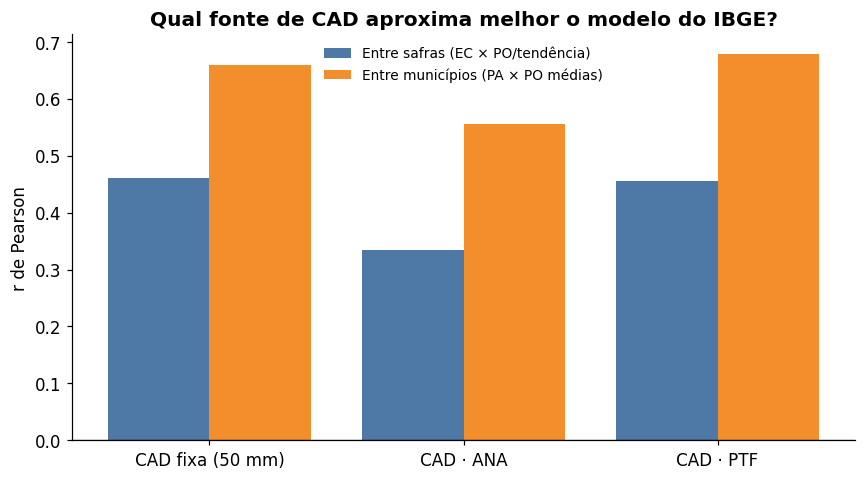

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
xr = np.arange(len(FONTES))
ax.bar(xr - 0.2, resultado['r_entre_anos'], width=0.4, color='#4e79a7', label='Entre safras (EC × PO/tendência)')
ax.bar(xr + 0.2, resultado['r_entre_municipios'], width=0.4, color='#f28e2b', label='Entre municípios (PA × PO médias)')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(xr)
ax.set_xticklabels(resultado.index)
ax.set_ylabel('r de Pearson')
ax.set_title('Qual fonte de CAD aproxima melhor o modelo do IBGE?', fontweight='bold')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
salvar(fig, 'aula04_r_por_cad.png')
plt.show()

## 7.6 Eficiência agrícola e propriedades do solo

EA = PO / PA média de cada município, com a PA da CAD que teve melhor desempenho entre municípios. A pergunta é se o solo afeta a produtividade por vias que o MZA não representa.

Figura salva em: figuras/aula04_ea_solo.png


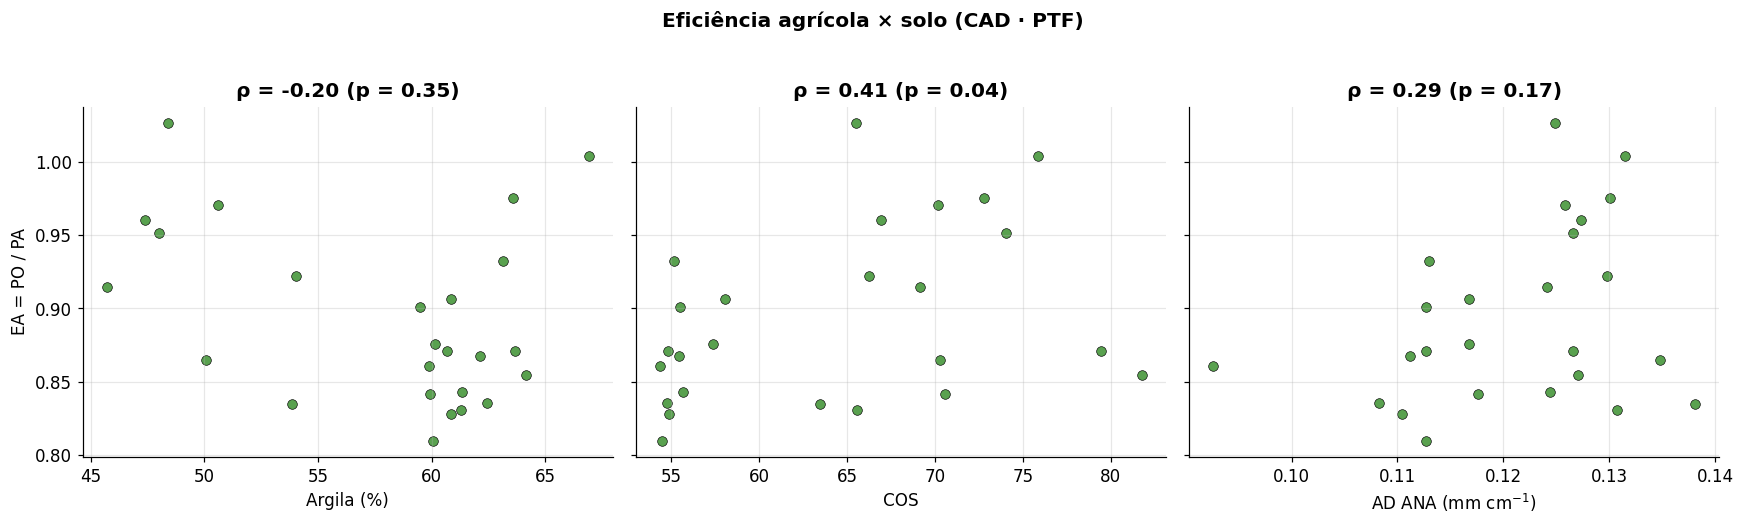

,PA,PO,EA,name_muni,argila,COS,AD_ANA
code_muni,,,,,,,
4127502,3642.253,3739.2,1.027,Tibagi,48.381,65.491,0.125
4114401,3817.549,3831.1,1.004,Mangueirinha,66.898,75.869,0.131
4104428,3856.362,3760.5,0.975,Candói,63.561,72.785,0.130
4117701,3768.918,3657.8,0.971,Palmeira,50.604,70.195,0.126
4119905,3924.238,3768.5,0.960,Ponta Grossa,47.370,66.951,0.127
4104907,3985.487,3792.7,0.952,Castro,47.990,74.024,0.127
4104303,3758.854,3503.3,0.932,Campo Mourão,63.143,55.129,0.113
4127007,3881.367,3578.0,0.922,Teixeira Soares,54.029,66.230,0.130
4119400,4126.439,3774.3,0.915,Piraí do Sul,45.713,69.146,0.124


In [ ]:
melhor = resultado['r_entre_municipios'].idxmax()
fonte_melhor = [k for k, v in ROTULOS.items() if v == melhor][0]
ea = (base[base['CAD'] == fonte_melhor].groupby('code_muni')[['PA', 'PO']].mean()
      .assign(EA=lambda t: t['PO'] / t['PA'])
      .join(sel.set_index('code_muni')[['name_muni', 'argila', 'COS', 'AD_ANA']]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=True)
for ax, var, rot in zip(axes, ['argila', 'COS', 'AD_ANA'],
                        ['Argila (%)', 'COS', 'AD ANA (mm cm$^{-1}$)']):
    rho_, p_ = spearmanr(ea[var], ea['EA'])
    ax.scatter(ea[var], ea['EA'], s=40, color='#59a14f', edgecolor='black', lw=0.4)
    ax.set_xlabel(rot)
    ax.set_title(f'ρ = {rho_:.2f} (p = {p_:.2f})', fontweight='bold')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('EA = PO / PA')
fig.suptitle(f'Eficiência agrícola × solo ({ROTULOS[fonte_melhor]})', fontweight='bold', y=1.03)
plt.tight_layout()
salvar(fig, 'aula04_ea_solo.png')
plt.show()

ea.sort_values('EA', ascending=False).round(3)

## Para discutir

1. Qual variável do solo responde mais ao clima? E qual esquema climático, Köppen ou Holdridge, separa melhor cada uma?
2. Em quais classes texturais a ANA e a pedotransferência mais discordam? Como a escolha de `MO_PTF` muda isso?
3. A CAD do solo melhorou a correlação com o IBGE? Por que a melhora pode ser pequena entre safras, mas maior entre municípios (ou o contrário)?
4. Se a EA aumentar com o carbono, o que isso diz sobre o que o MZA deixa de representar?

## Referências

SAXTON, K. E.; RAWLS, W. J. Soil water characteristic estimates by texture and organic matter for hydrologic solutions. **Soil Science Society of America Journal**, v. 70, n. 5, p. 1569-1578, 2006.

XAVIER, A. C. et al. New improved Brazilian daily weather gridded data (1961–2020). **International Journal of Climatology**, v. 42, n. 16, p. 8390-8404, 2022.

ABATZOGLOU, J. T. et al. TerraClimate, a high-resolution global dataset of monthly climate and climatic water balance from 1958–2015. **Scientific Data**, v. 5, 170191, 2018.